# 01 Supervised Learning

This notebook records my practice for supervised learning from *Introduction to Machine Learning with Python*.

## Goals

- Understand classification and regression
- Practice train-test split
- Train a simple machine learning model
- Evaluate model performance


## Forge Dataset

This is a synthetic two-class classification dataset.

- X represents input features
- y represents labels
- X.shape = (26, 2), meaning 26 samples and 2 features

In [ ]:
import mglearn
import matplotlib.pyplot as plt

X, y = mglearn.datasets.make_forge()

mglearn.discrete_scatter(X[:, 0], X[ :, 1], y)
plt.legend(["Class 0", "Class 1"], loc=4)
plt.xlabel("First feature")
plt.ylabel("Second feature")

print("X.shape:", X.shape)

## Cancer dataset

In [ ]:
from sklearn.datasets import  load_breast_cancer
cancer = load_breast_cancer()
print(f"cancer.keys(): \n{cancer.keys()}")
print(f"shape of dataset:{cancer.data.shape}")
sample_counts = {str(n) : int(v) for n, v in zip(cancer.target_names, np.bincount(cancer.target))}
print(f"sample couunts per class: \n{sample_counts}")
print(f"feature names: \n{cancer.feature_names}")


 apply the k-nearest neighbors algorithm using scikit-learn

In [24]:
#split our data into a training and a test set
from sklearn.model_selection import train_test_split
X, y = mglearn.datasets.make_forge()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

# import and instantiate the class
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)

#fit the classifier using the training set
clf.fit(X_train, y_train)

#make predictions on the test data
print(f"Test set predictions:{clf.predict(X_test)}")

# evaluation
print(f"Test set accuracy:{(clf.score(X_test, y_test))}")

Test set predictions:[1 0 1 0 1 0 0]
Test set accuracy:0.8571428571428571


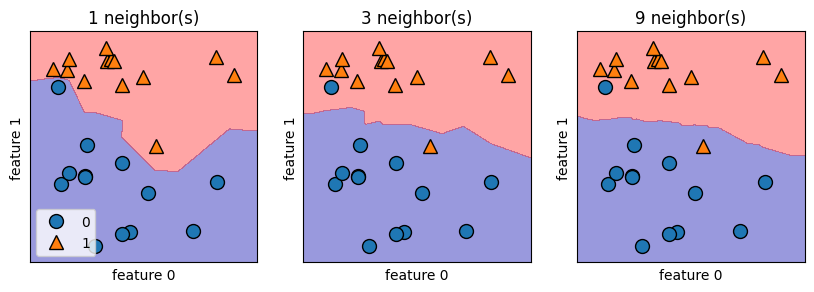

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for n_neighbors, ax in zip([1, 3, 9], axes):
# the fit method returns the object self, so we can instantiate
# and fit in one line
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
    mglearn.plots.plot_2d_separator(clf, X, fill=True, eps=0.5, ax=ax, alpha=.4)
    mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)
    ax.set_title("{} neighbor(s)".format(n_neighbors))
    ax.set_xlabel("feature 0")
    ax.set_ylabel("feature 1")
axes[0].legend(loc=3)